#### *Now as we have done with EDA and Data Preprocessing , finally its time to train our models using various algorithms and with different encoding techniques*

#### ***Model Building***

In [2]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('Modelling_data.csv')

In [4]:
data.sample(4)

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
4838,54839,0,22.0,Phone,1,27.0,card,Male,3.0,4.0,Phone,3,Married,6,0,18.0,2.0,2.0,1.0,147.59
3166,53167,0,1.0,Phone,1,24.0,UPI,Male,4.0,5.0,Phone,4,Divorced,3,0,22.0,2.0,2.0,1.0,146.27
2768,52769,0,0.0,Phone,1,7.0,card,Male,3.0,3.0,Phone,3,Single,1,0,12.0,1.0,1.0,2.0,133.75
921,50922,0,17.0,Phone,1,26.0,card,Male,2.0,3.0,Phone,4,Single,2,0,13.0,1.0,1.0,3.0,134.20


In [5]:
cat_cols = data.select_dtypes(include=['object']).columns
num_cols = data.select_dtypes(include=['int64','float64']).columns

cat_cols, num_cols

(Index(['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
        'PreferedOrderCat', 'MaritalStatus'],
       dtype='object'),
 Index(['CustomerID', 'Churn', 'Tenure', 'CityTier', 'WarehouseToHome',
        'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore',
        'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear',
        'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount'],
       dtype='object'))

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

In [7]:
X = data.drop('Churn', axis=1)
y = data['Churn']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
from imblearn.over_sampling import SMOTE

In [10]:
stdscl_cols = ['Tenure', 'WarehouseToHome',
           'HourSpendOnApp', 'NumberOfDeviceRegistered',
           'NumberOfAddress', 'OrderAmountHikeFromlastYear',
           'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 
            'CashbackAmount']

#### Model Training using **LOGISTIC REGRESSION**

In [11]:
from sklearn.linear_model import LogisticRegression

In [59]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), stdscl_cols)
    ]
)

In [60]:
log_reg_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=300))
])

In [61]:
# Hyperparameter Tuning                                                         
param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 50],
    'model__penalty': ['l2'],  # L1 only works with liblinear/saga
    'model__solver': ['lbfgs', 'newton-cg', 'liblinear'],
    'model__class_weight': [None, 'balanced']
}

**Using GridSearchCV for better hyperparameter tuning**

In [62]:
# Grid Search
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

log_reg_grid = GridSearchCV(log_reg_pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

In [63]:
log_reg_grid.fit(X_train, y_train)

,estimator,Pipeline(step...x_iter=300))])
,param_grid,"{'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced'], 'model__penalty': ['l2'], 'model__solver': ['lbfgs', 'newton-cg', ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cat', ...), ('num', ...)]"


In [64]:
print("Best Parameters:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)

Best Parameters: {'model__C': 0.1, 'model__class_weight': None, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best Accuracy: 0.8634532001479837


In [66]:
y_pred = log_reg_grid.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.8756660746003553


In [67]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8756660746003553

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.97      0.93       941
           1       0.74      0.37      0.50       185

    accuracy                           0.88      1126
   macro avg       0.81      0.67      0.71      1126
weighted avg       0.86      0.88      0.86      1126



#### Model Training using **Random Forest**

In [20]:
from sklearn.ensemble import RandomForestClassifier

In [29]:
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [68]:
rfpipeline = Pipeline(steps=[
    ('model', RandomForestClassifier(
        n_estimators = 100, 
        max_depth = None, 
        random_state = 42
    ))
])

In [69]:
rfpipeline.fit(X_train, y_train)

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'


In [70]:
y_pred = rfpipeline.predict(X_test)

In [71]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9635879218472468

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       941
           1       0.99      0.78      0.88       185

    accuracy                           0.96      1126
   macro avg       0.98      0.89      0.93      1126
weighted avg       0.96      0.96      0.96      1126



#### Model Training using **XG Boost**

In [72]:
from xgboost import XGBClassifier

In [73]:
xgbpipe = Pipeline(steps=[
    ('model', XGBClassifier(
        n_estimators=2000,
        learning_rate=0.08,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    ))
])

In [86]:
xgb_model = xgbpipe.named_steps['model']

In [81]:
xgbpipe.fit(X_train,y_train)

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8


In [75]:
y_pred = xgbpipe.predict(X_test)

In [76]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.977797513321492

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       941
           1       0.99      0.87      0.93       185

    accuracy                           0.98      1126
   macro avg       0.98      0.93      0.96      1126
weighted avg       0.98      0.98      0.98      1126



**Applying GridsearchCV on XGBoost for improving efficiency**

In [40]:
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

In [41]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    
}

In [42]:
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

In [43]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 243 candidates, totalling 729 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [44]:
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 1.0}
Best Accuracy: 0.9476023234103733


**There is no advantage of using GridSearchCV**

**Applying RandomizedSearchCV....**

In [45]:
from scipy.stats import uniform, randint

In [46]:
param2_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 5),
    'min_child_weight': randint(1, 10)
}


In [47]:
rand_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param2_dist,
    n_iter=30,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)


In [48]:
rand_search.fit(X_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': <scipy.stats....00295740B7D90>, 'gamma': <scipy.stats....002956E917950>, 'learning_rate': <scipy.stats....002956E82B770>, 'max_depth': <scipy.stats....00295740B6710>, ...}"
,n_iter,30
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [49]:
print("Best Parameters:", rand_search.best_params_)
print("Best Accuracy:", rand_search.best_score_)

Best Parameters: {'colsample_bytree': np.float64(0.7297380084021096), 'gamma': np.float64(0.6104397735033668), 'learning_rate': np.float64(0.11688935142309247), 'max_depth': 8, 'min_child_weight': 1, 'n_estimators': 484, 'subsample': np.float64(0.6911740650167767)}
Best Accuracy: 0.9353919402156219


***So most efficient Accuracy: 97.7797513321492***

#### This accuracy is obtained by pure XGBCLassifier with best hyperparameters as : 
`n_estimators=2000, learning_rate=0.08, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric='logloss'`

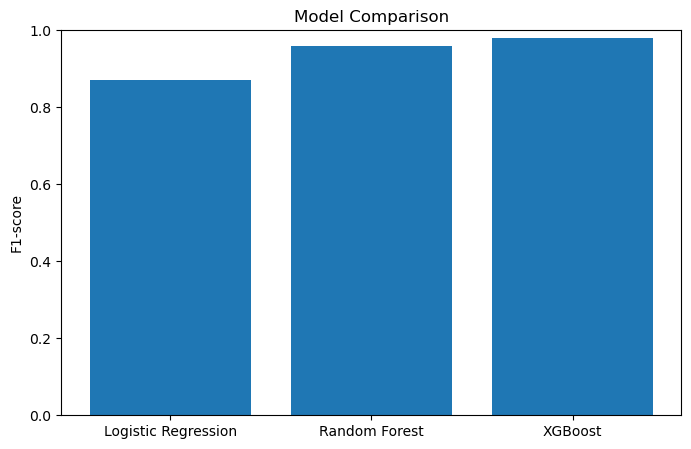

In [50]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Random Forest', 'XGBoost']
scores = [0.87, 0.96, 0.98]   # example F1 scores

plt.figure(figsize=(8,5))
plt.bar(models, scores)
plt.ylabel("F1-score")
plt.title("Model Comparison")
plt.ylim(0,1)
plt.show()


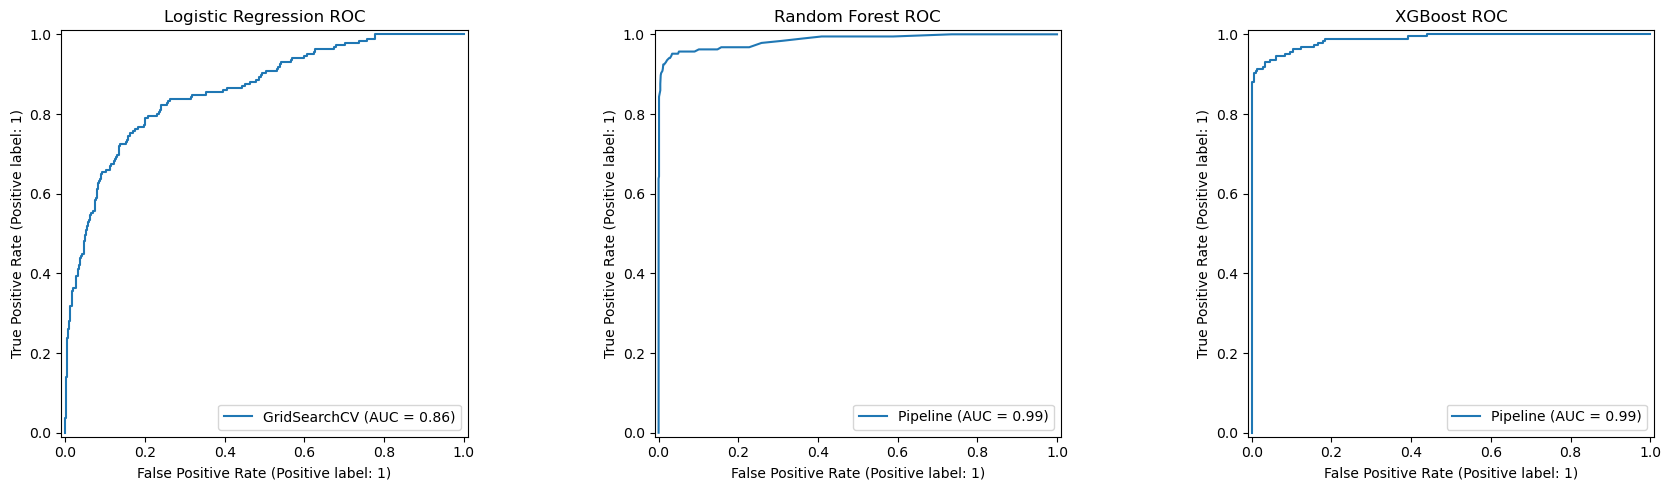

In [79]:
from sklearn.metrics import RocCurveDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Logistic Regression ROC
RocCurveDisplay.from_estimator(log_reg_grid, X_test, y_test, ax=axes[0])
axes[0].set_title("Logistic Regression ROC")

# Random Forest ROC
RocCurveDisplay.from_estimator(rfpipeline, X_test, y_test, ax=axes[1])
axes[1].set_title("Random Forest ROC")

# XGBoost ROC
RocCurveDisplay.from_estimator(xgbpipe, X_test, y_test, ax=axes[2])
axes[2].set_title("XGBoost ROC")

plt.tight_layout()
plt.show()


In [83]:
pip install shap

   ---------------------------------------- 0.0/549.1 kB ? eta -:--:--
   ---------------------------------------- 549.1/549.1 kB 7.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------- ----------------- 1.6/2.7 MB 7.4 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 7.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   - -------------------------------------- 1.6/38.1 MB 7.6 MB/s eta 0:00:05
   --- ------------------------------------ 3.1/38.1 MB 7.4 MB/s eta 0:00:05
   ---- ----------------------------------- 4.5/38.1 MB 7.4 MB/s eta 0:00:05
   ------ --------------------------------- 6.0/38.1 MB 7.4 MB/s eta 0:00:05
   ------- -------------------------------- 7.6/38.1 MB 7.4 MB/s eta 0:00:05
   --------- ------------------------------ 9.2/38.1 MB 7.3 MB/s eta 0:00:04
   ----------- ---------------------------- 10.7/38.1 MB 7.3 MB/s eta 0:00:04
   ------------ --

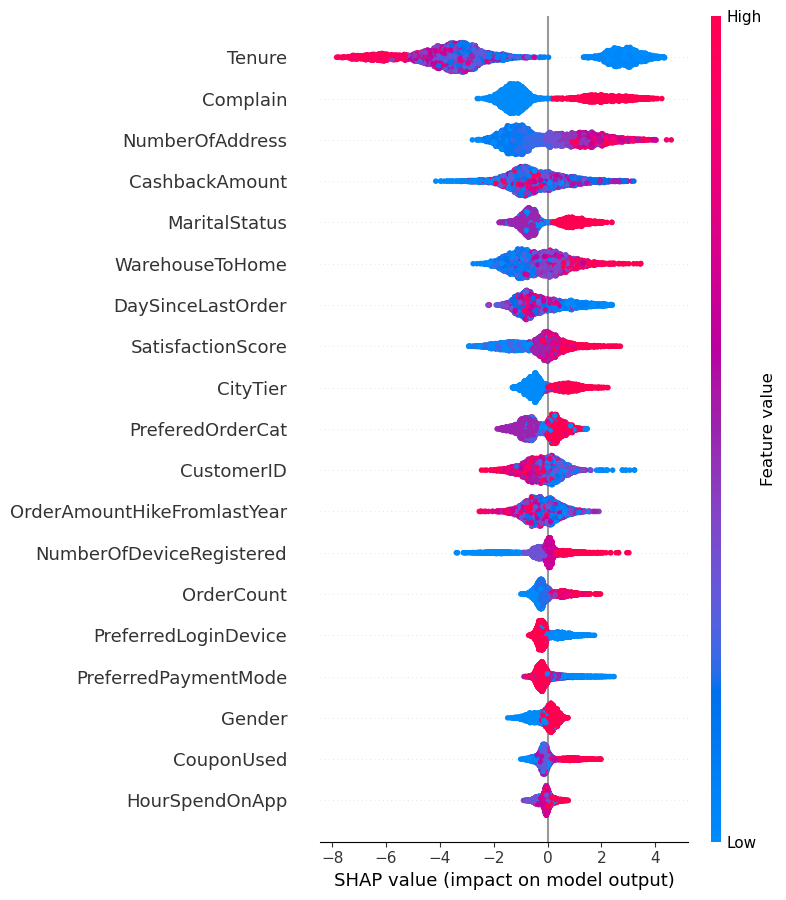

In [89]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train)


In [ ]:
PreferedOrderCat
CustomerId
OrderAmountHikelastYear
NumberOfDeviceRegistered
OrderCount
PreferredLoginDevice
PreferredPaymentMode
Gender
CouponUsed
HourSpendOnApp